In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import fetch_openml

In [5]:
print("environment ready")
housing = fetch_openml(name="house_prices", as_frame = True)

environment ready


In [ ]:
//housing.frame
//contient les deux ensemble :features + target

In [ ]:
df = housing.frame //housing n’est pas directement le tableau. C’est un objet qui contient plusieurs éléments du dataset.
df.shape

(1460, 81)

In [ ]:
df.head()//montre les 5 premieres lignes de dataframe

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
df["SalePrice"].head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [10]:
df["OverallQual"].head()

0    7
1    6
2    7
3    7
4    8
Name: OverallQual, dtype: int64

In [13]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [15]:
df.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageFinish      81
GarageQual        81
GarageYrBlt       81
GarageType        81
dtype: int64

In [17]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False).head(10)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
FireplaceQu     47.260274
LotFrontage     17.739726
GarageFinish     5.547945
GarageQual       5.547945
GarageYrBlt      5.547945
GarageType       5.547945
dtype: float64

In [19]:
df["PoolQC"].value_counts(dropna=False)

PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

In [21]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

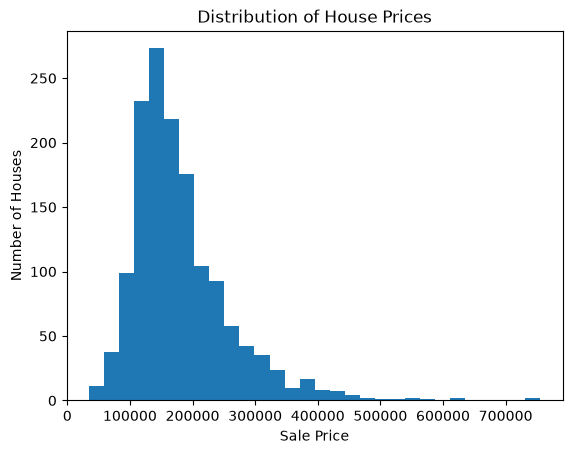

In [22]:
plt.hist(df["SalePrice"], bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

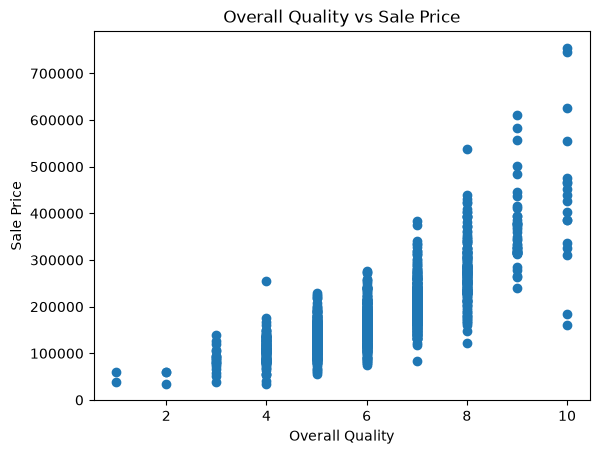

In [23]:
plt.scatter(df["OverallQual"], df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Overall Quality vs Sale Price")
plt.show()

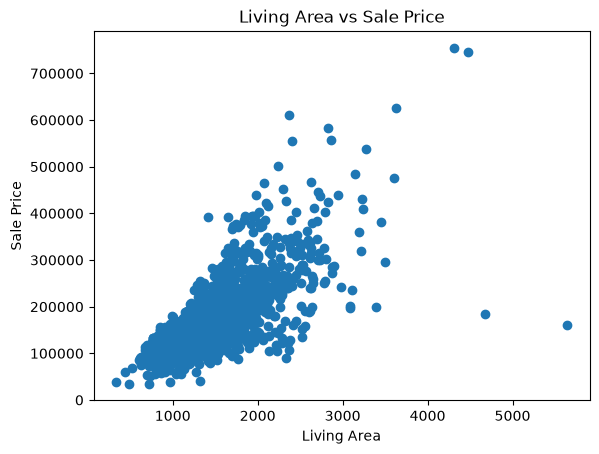

In [24]:
plt.scatter(df["GrLivArea"], df["SalePrice"])
plt.xlabel("Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs Sale Price")
plt.show()

In [25]:
df["OverallQual"].corr(df["SalePrice"])

np.float64(0.7909816005838051)

In [26]:
df["GrLivArea"].corr(df["SalePrice"])

np.float64(0.7086244776126521)

In [31]:
numeric_df=df.select_dtypes(include=["number"])
correlations = numeric_df.corr()["SalePrice"].sort_values(ascending=False)
correlations.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64